<a href="https://colab.research.google.com/github/aayushrouniyarcs24-cmd/BIOS-LAB/blob/main/1BF24CS010_BIOSLAB_Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generation  20 | Best Sharpe Ratio: 0.5727
Generation  40 | Best Sharpe Ratio: 0.5728
Generation  60 | Best Sharpe Ratio: 0.5728
Generation  80 | Best Sharpe Ratio: 0.5728
Generation 100 | Best Sharpe Ratio: 0.5728
Generation 120 | Best Sharpe Ratio: 0.5728
Generation 140 | Best Sharpe Ratio: 0.5728
Generation 160 | Best Sharpe Ratio: 0.5728
Generation 180 | Best Sharpe Ratio: 0.5728
Generation 200 | Best Sharpe Ratio: 0.5728

OPTIMAL PORTFOLIO
Asset_A   :  19.35%
Asset_B   :  19.16%
Asset_C   :  30.34%
Asset_D   :   0.00%
Asset_E   :  31.15%

Portfolio Statistics
--------------------------------------------------
Expected Annual Return : 12.84%
Annual Volatility      : 13.69%
Risk-Free Rate         : 5.00%
Sharpe Ratio            : 0.5728


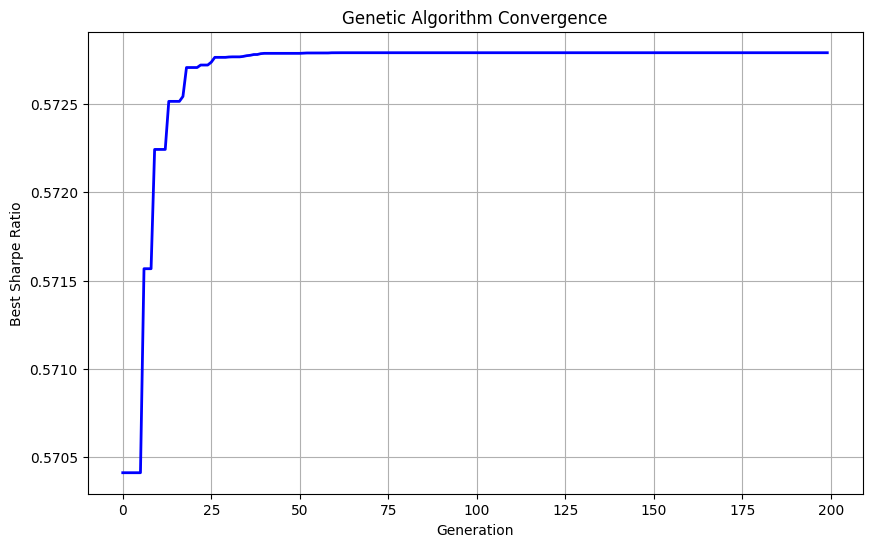

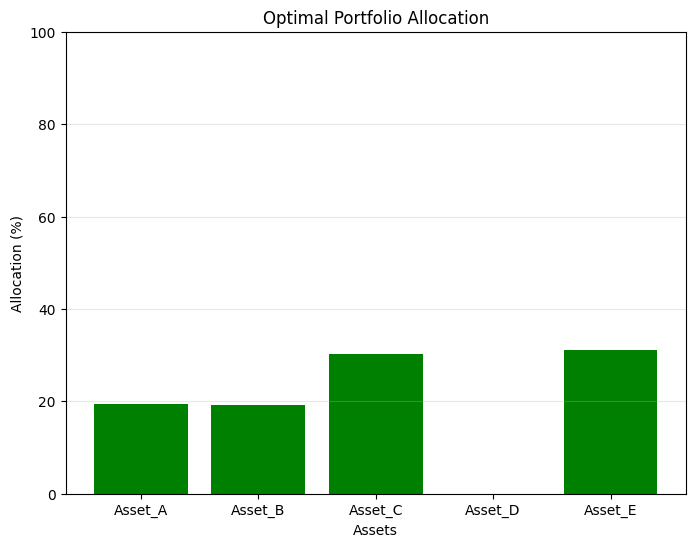

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. SAMPLE FINANCIAL DATA
# ============================================================

# Asset names
assets = ["Asset_A", "Asset_B", "Asset_C", "Asset_D", "Asset_E"]

# Expected annual returns (example data)
expected_returns = np.array([
    0.12,   # Asset A
    0.10,   # Asset B
    0.15,   # Asset C
    0.08,   # Asset D
    0.13    # Asset E
])

# Annualized covariance matrix (example data)
covariance_matrix = np.array([
    [0.040, 0.010, 0.012, 0.008, 0.011],
    [0.010, 0.025, 0.009, 0.006, 0.008],
    [0.012, 0.009, 0.050, 0.010, 0.015],
    [0.008, 0.006, 0.010, 0.016, 0.007],
    [0.011, 0.008, 0.015, 0.007, 0.035]
])

# Risk-free rate
risk_free_rate = 0.05


# ============================================================
# 2. PORTFOLIO CALCULATIONS
# ============================================================

def portfolio_return(weights):
    """
    Calculate expected portfolio return.
    """
    return np.dot(weights, expected_returns)


def portfolio_variance(weights):
    """
    Calculate portfolio variance.
    """
    return np.dot(weights.T, np.dot(covariance_matrix, weights))


def portfolio_volatility(weights):
    """
    Calculate portfolio volatility.
    """
    return np.sqrt(portfolio_variance(weights))


def sharpe_ratio(weights):
    """
    Calculate annualized Sharpe ratio.
    """
    ret = portfolio_return(weights)
    risk = portfolio_volatility(weights)

    if risk == 0:
        return 0

    return (ret - risk_free_rate) / risk


# ============================================================
# 3. INITIAL POPULATION
# ============================================================

population_size = 100
num_assets = len(assets)

mutation_rate = 0.10
crossover_rate = 0.80
num_generations = 200


def create_population():
    """
    Create initial population.

    Each chromosome represents a portfolio.
    The chromosome contains weights for each asset.
    """

    population = []

    for _ in range(population_size):

        # Generate random portfolio weights
        weights = np.random.random(num_assets)

        # Normalize weights so that they sum to 1
        weights = weights / np.sum(weights)

        population.append(weights)

    return np.array(population)


# ============================================================
# 4. FITNESS EVALUATION
# ============================================================

def calculate_fitness(population):
    """
    Calculate fitness for every portfolio.
    """

    fitness = []

    for individual in population:
        fitness.append(sharpe_ratio(individual))

    return np.array(fitness)


# ============================================================
# 5. SELECTION
# ============================================================

def selection(population, fitness):
    """
    Tournament selection.

    Two random individuals are selected and the one
    with higher fitness becomes a parent.
    """

    selected = []

    for _ in range(population_size):

        # Randomly select two individuals
        i = np.random.randint(0, population_size)
        j = np.random.randint(0, population_size)

        # Select the fitter individual
        if fitness[i] > fitness[j]:
            winner = population[i]
        else:
            winner = population[j]

        selected.append(winner)

    return np.array(selected)


# ============================================================
# 6. CROSSOVER
# ============================================================

def crossover(parent1, parent2):
    """
    Perform arithmetic crossover.
    """

    if np.random.random() < crossover_rate:

        alpha = np.random.random()

        child1 = alpha * parent1 + (1 - alpha) * parent2
        child2 = alpha * parent2 + (1 - alpha) * parent1

    else:

        child1 = parent1.copy()
        child2 = parent2.copy()

    # Normalize portfolio weights
    child1 = child1 / np.sum(child1)
    child2 = child2 / np.sum(child2)

    return child1, child2


# ============================================================
# 7. MUTATION
# ============================================================

def mutation(individual):
    """
    Randomly mutate portfolio weights.
    """

    mutated = individual.copy()

    for i in range(num_assets):

        if np.random.random() < mutation_rate:

            # Add small random change
            mutated[i] += np.random.normal(0, 0.05)

    # Prevent negative weights
    mutated = np.maximum(mutated, 0)

    # Normalize weights
    if np.sum(mutated) == 0:
        mutated = np.ones(num_assets) / num_assets
    else:
        mutated = mutated / np.sum(mutated)

    return mutated


# ============================================================
# 8. GENETIC ALGORITHM
# ============================================================

def genetic_algorithm():

    # Create initial population
    population = create_population()

    best_solution = None
    best_fitness = -np.inf

    history = []

    for generation in range(num_generations):

        # --------------------------------------------
        # Evaluate fitness
        # --------------------------------------------

        fitness = calculate_fitness(population)

        # Find best individual
        best_index = np.argmax(fitness)

        current_best = population[best_index]
        current_fitness = fitness[best_index]

        # Store global best
        if current_fitness > best_fitness:

            best_fitness = current_fitness
            best_solution = current_best.copy()

        history.append(best_fitness)

        # --------------------------------------------
        # Selection
        # --------------------------------------------

        selected_population = selection(population, fitness)

        # --------------------------------------------
        # Crossover + Mutation
        # --------------------------------------------

        new_population = []

        for i in range(0, population_size, 2):

            parent1 = selected_population[i]

            if i + 1 < population_size:
                parent2 = selected_population[i + 1]
            else:
                parent2 = selected_population[0]

            # Crossover
            child1, child2 = crossover(parent1, parent2)

            # Mutation
            child1 = mutation(child1)
            child2 = mutation(child2)

            new_population.append(child1)
            new_population.append(child2)

        population = np.array(new_population[:population_size])

        # Display progress
        if (generation + 1) % 20 == 0:

            print(
                f"Generation {generation + 1:3d} | "
                f"Best Sharpe Ratio: {best_fitness:.4f}"
            )

    return best_solution, best_fitness, history


# ============================================================
# 9. RUN GENETIC ALGORITHM
# ============================================================

best_weights, best_sharpe, history = genetic_algorithm()


# ============================================================
# 10. DISPLAY RESULTS
# ============================================================

best_return = portfolio_return(best_weights)
best_risk = portfolio_volatility(best_weights)

print("\n" + "=" * 50)
print("OPTIMAL PORTFOLIO")
print("=" * 50)

for asset, weight in zip(assets, best_weights):

    print(
        f"{asset:10s}: {weight * 100:6.2f}%"
    )

print("\nPortfolio Statistics")
print("-" * 50)

print(f"Expected Annual Return : {best_return * 100:.2f}%")
print(f"Annual Volatility      : {best_risk * 100:.2f}%")
print(f"Risk-Free Rate         : {risk_free_rate * 100:.2f}%")
print(f"Sharpe Ratio            : {best_sharpe:.4f}")


# ============================================================
# 11. CONVERGENCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history,
    color="blue",
    linewidth=2
)

plt.title(
    "Genetic Algorithm Convergence"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Best Sharpe Ratio"
)

plt.grid(True)

plt.show()


# ============================================================
# 12. PORTFOLIO ALLOCATION GRAPH
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    assets,
    best_weights * 100,
    color="green"
)

plt.title(
    "Optimal Portfolio Allocation"
)

plt.xlabel(
    "Assets"
)

plt.ylabel(
    "Allocation (%)"
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()
